In [108]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
import os 
from run_experiment import load_model_from_run_dir, load_raw_data
from utils import BinnedStimSpikeDataset, bin_spike_response
from viz import compute_avg_spikes_across_trials
import yaml

n_neurons = 63
n_stim_channels = 42

def open_model_and_data(results_dir):
    model = load_model_from_run_dir(results_dir, n_stim_channels=n_stim_channels, n_neurons=n_neurons)  
    with open(os.path.join(results_dir, "config.yaml"), "r") as f:
        cfg = yaml.safe_load(f)
        output_bin_size_ms = cfg['output_bin_size_ms']
        max_time_ms = cfg['max_time_ms']

        raw_data = load_raw_data(cfg, logger=None) # pattern df, spike_responses, etc. 

        # Auto-compute n_initial_state_bins for CNN + init_state
        # Only valid-conv reduction; history lookback is handled in __getitem__
        n_initial_state_bins = cfg.get('n_initial_state_bins', 1)
        if cfg.get('init_state', False) and cfg.get('model_type', 'cnn') == 'cnn':
            _ks = cfg.get('kernel_sizes', [60])
            n_initial_state_bins = sum(k - 1 for k in _ks)

        history_dataset_kwargs = dict(
            pattern_df=raw_data["pattern_df"],
            spike_responses=raw_data["spike_responses"],
            channel_to_index=raw_data["channel_to_index"],
            timing_to_pattern=raw_data["timing_to_pattern"],
            input_bin_size_ms=cfg['input_bin_size_ms'],
            output_bin_size_ms=cfg['output_bin_size_ms'],
            n_input_bins=cfg['n_input_bins'],
            n_output_bins=cfg['n_output_bins'],
            max_time_ms=cfg['max_time_ms'],
            output_offset=cfg['output_offset'],
            encoding_mode=cfg['encoding_mode'],
            init_state=cfg['init_state'],
            n_initial_state_bins=n_initial_state_bins,
            history=cfg['history'],
            logger=None,
        )


    unique_trials_info = raw_data["pattern_df"][["pattern_timing_index", "pattern_name", "is_oracle"]].drop_duplicates()
    oracle_timing = unique_trials_info[unique_trials_info["is_oracle"]]["pattern_timing_index"].tolist()
    test_indices = oracle_timing
    test_dataset = BinnedStimSpikeDataset(trial_indices=test_indices, **history_dataset_kwargs)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    return model, cfg, raw_data, test_loader


def get_oracle_trial_response_and_loo_average(raw_data, pattern_name):
    spike_responses = raw_data["spike_responses"]
    pattern_df = raw_data["pattern_df"]
    timing_list = sorted(pattern_df[pattern_df['pattern_name'] == pattern_name]['pattern_timing_index'].tolist())
    for trial_idx in range(len(timing_list)):
        timing_idx = timing_list[trial_idx]
        
        # Actual spike response - binned (spike_responses are in 1ms resolution)
        actual_response_binned = bin_spike_response(spike_responses[timing_idx], output_bin_size_ms, max_time_ms, remainder="append")
        
        # Average spikes across other trials
        other_trial_indices = [t for t in timing_list if t != timing_idx]
        avg_other_trials = compute_avg_spikes_across_trials(
            other_trial_indices, spike_responses, output_bin_size_ms, max_time_ms
            )
    return actual_response_binned, avg_other_trials


            



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
history_model, history_cfg, history_raw, test_loader = open_model_and_data('results/hist_cnn_initstate_v3_2026-02-19_18-40-39/trial_0000_history=1/')
nonhistory_model, nonhistory_cfg, nonhistory_raw, nonhistory_test_loader = open_model_and_data('results/base_cnn_sweep3_2026-02-20_11-17-00/trial_0025/')


Loading data …
63 unique neurons after dropping problematic neurons
Stimulation channels: 42, Spiking neurons: 63
Unique patterns: 4050, Total trials: 5000
Added init state spikes for trial  -1  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  0  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes for trial  3  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  4  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes for trial  8  from non-specified set of

In [54]:
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from collections import defaultdict

# --- Helper: run model on its test loader, return per-neuron temporal correlation ---
def get_per_neuron_temporal_corr(model_tuple, loader, coarse_factor=0):
    """
    Concatenate all (sample × time-bin) predictions and targets,
    then compute Pearson r per neuron across the full time-series.
    
    Returns array of shape (n_neurons,).
    """
    model, _, device = model_tuple
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            bx, by = batch[0].to(device), batch[1]
            pred = torch.exp(model(bx)).cpu().numpy()   # (B, neurons, bins)
            all_pred.append(pred)
            all_true.append(by.numpy())
    all_pred = np.concatenate(all_pred, axis=0)  # (N, neurons, bins)
    all_true = np.concatenate(all_true, axis=0)
    if coarse_factor > 0:
        all_pred = _coarsen(all_pred, factor=coarse_factor)
        all_true = _coarsen(all_true, factor=coarse_factor)
    n_neurons = all_pred.shape[1]

    corrs = np.zeros(n_neurons)
    for n in range(n_neurons):
        p = all_pred[:, n, :].ravel()
        t = all_true[:, n, :].ravel()
        if p.std() > 1e-8 and t.std() > 1e-8:
            corrs[n] = pearsonr(p, t)[0]
    return corrs


def collect_model_preds_and_targets(model_tuple, loader, coarse_factor=0):
    """Return (all_pred, all_true) as arrays of shape (N, neurons, bins)."""
    model, _, device = model_tuple
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            bx, by = batch[0].to(device), batch[1]
            pred = torch.exp(model(bx)).cpu().numpy()
            all_pred.append(pred)
            all_true.append(by.numpy())
    all_pred = np.concatenate(all_pred, axis=0)
    all_true = np.concatenate(all_true, axis=0)
    if coarse_factor > 0:
        all_pred = _coarsen(all_pred, factor=coarse_factor)
        all_true = _coarsen(all_true, factor=coarse_factor)
    return all_pred, all_true

def collect_loo_preds_and_targets(test_dataset, coarse_factor=0, loo_flag=True):
    """Return (loo_pred, true) as arrays of shape (N, neurons, bins)."""
    pattern_to_timings = defaultdict(list)
    for timing_idx in test_dataset.trial_indices:
        pname = test_dataset.timing_to_pattern[timing_idx]
        pattern_to_timings[pname].append(timing_idx)

    n_neurons = test_dataset.n_neurons
    n_fine_bins = test_dataset.n_output_bins
    n_out_bins = n_fine_bins // coarse_factor if coarse_factor > 0 else n_fine_bins
    n_samples = len(test_dataset)

    all_true = np.zeros((n_samples, n_neurons, n_out_bins), dtype=np.float32)
    all_loo  = np.zeros((n_samples, n_neurons, n_out_bins), dtype=np.float32)

    for i in range(n_samples):
        timing_idx, t = test_dataset.samples[i]
        pname = test_dataset.timing_to_pattern[timing_idx]
        spikes_full = test_dataset.spike_responses_binned[timing_idx]
        out_start = t + test_dataset.output_offset
        y = spikes_full[:, out_start : out_start + n_fine_bins]

        other_timings = [ti for ti in pattern_to_timings[pname] if ti != timing_idx]
        if not loo_flag: # add original trial to get a full sample mean
            other_timings.append(timing_idx)

        if len(other_timings) == 0:
            loo = np.zeros_like(y)
        else:
            acc = np.zeros_like(y, dtype=np.float64)
            for oti in other_timings:
                other = test_dataset.spike_responses_binned[oti]
                acc += other[:, out_start : out_start + n_fine_bins]
            loo = acc / len(other_timings)

        if coarse_factor > 0:
            trim = n_out_bins * coarse_factor
            y   = y[:, :trim].reshape(n_neurons, n_out_bins, coarse_factor).mean(axis=2)
            loo = loo[:, :trim].reshape(n_neurons, n_out_bins, coarse_factor).mean(axis=2)

        all_true[i] = y
        all_loo[i]  = loo

    return all_loo, all_true

# --- Helper: LOO temporal correlation ---
def get_loo_temporal_corr(test_dataset, coarse_factor=0):
    """
    For each sample, the LOO 'prediction' is the average of all other
    trials of the same pattern (same time offset).  Pearson r is computed
    per neuron across the concatenated time-series of all samples.
    """
    # Map pattern → list of timing indices
    pattern_to_timings = defaultdict(list)
    for timing_idx in test_dataset.trial_indices:
        pname = test_dataset.timing_to_pattern[timing_idx]
        pattern_to_timings[pname].append(timing_idx)

    n_neurons = test_dataset.n_neurons
    n_fine_bins = test_dataset.n_output_bins          # always read full fine resolution
    n_out_bins = n_fine_bins // coarse_factor if coarse_factor > 0 else n_fine_bins
    n_samples = len(test_dataset)

    flat_true = np.zeros((n_samples * n_out_bins, n_neurons), dtype=np.float32)
    flat_loo  = np.zeros((n_samples * n_out_bins, n_neurons), dtype=np.float32)

    cursor = 0
    for i in range(n_samples):
        timing_idx, t = test_dataset.samples[i]
        pname = test_dataset.timing_to_pattern[timing_idx]
        spikes_full = test_dataset.spike_responses_binned[timing_idx]
        out_start = t + test_dataset.output_offset
        y = spikes_full[:, out_start : out_start + n_fine_bins]  # (neurons, fine_bins)

        other_timings = [ti for ti in pattern_to_timings[pname] if ti != timing_idx]
        if len(other_timings) == 0:
            loo = np.zeros_like(y)
        else:
            acc = np.zeros_like(y, dtype=np.float64)
            for oti in other_timings:
                other = test_dataset.spike_responses_binned[oti]
                acc += other[:, out_start : out_start + n_fine_bins]
            loo = acc / len(other_timings)

        # Coarsen if needed: (neurons, fine_bins) → (neurons, coarse_bins)
        if coarse_factor > 0:
            trim = n_out_bins * coarse_factor
            y   = y[:, :trim].reshape(n_neurons, n_out_bins, coarse_factor).mean(axis=2)
            loo = loo[:, :trim].reshape(n_neurons, n_out_bins, coarse_factor).mean(axis=2)

        end = cursor + n_out_bins
        flat_true[cursor:end] = y.T
        flat_loo[cursor:end]  = loo.T
        cursor = end

    corrs = np.zeros(n_neurons)
    for n in range(n_neurons):
        p = flat_loo[:, n]
        t = flat_true[:, n]
        if p.std() > 1e-8 and t.std() > 1e-8:
            corrs[n] = pearsonr(p, t)[0]
    return corrs

def _coarsen(arr_3d, factor=0):
    """Average (N, neurons, fine_bins) → (N, neurons, coarse_bins) by reshaping."""
    if factor == 0:
        print ("No coarsening applied (factor=0), returning original array.")
        return arr_3d
    N, neurons, fine = arr_3d.shape
    coarse = fine // factor
    trimmed = arr_3d[:, :, :coarse * factor]  # drop remainder bins if any
    return trimmed.reshape(N, neurons, coarse, factor).mean(axis=3)

def fraction_variance_explained(y_true, y_pred, global_variance=False):
    """
    y_pred and y_true are shape (batch, neurons, time)
    Returns:
        neuron_r2: (neurons,) - R2 averaged over the batch
        mean_r2: float - Global average R2
    """
    assert y_pred.shape == y_true.shape
    batch_size, num_neurons, _ = y_true.shape

    # 1. Determine the Mean to subtract
    if global_variance:
        # Mean across ALL patterns (batch) and time
        # Shape becomes (1, neurons, 1) for broadcasting
        mu = y_true.mean(axis=(0, 2), keepdims=True) 
        numerator = np.sum((y_pred - y_true)**2, axis=(0, 2))  # sum over batch and time
        denominator = np.sum((y_true - mu)**2, axis=(0, 2))  # sum over batch and time
    else:
        # Mean per pattern and per neuron
        # Shape becomes (batch, neurons, 1)
        mu = y_true.mean(axis=2, keepdims=True)
        numerator = np.sum((y_pred - y_true)**2, axis=2)
        denominator = np.sum((y_true - mu)**2, axis=2)


    # 3. Handle division by zero (constant firing rates)
    # If denominator is tiny, the variance is 0. 
    # Usually we mask these out or set R2 to 0 (or 1 depending on philosophy, here using your mask approach)
    valid_mask = denominator > 1e-10
    
    # Initialize grid of R2 values
    if global_variance:
        r_squared_batch_neuron = np.zeros((num_neurons,))  # only one R2 per neuron
    else:   
        r_squared_batch_neuron = np.zeros((batch_size, num_neurons))
    
    # Perform division only where valid
    # Note: We must index both arrays with the mask to maintain shape alignment
    r_squared_batch_neuron[valid_mask] = 1 - (numerator[valid_mask] / denominator[valid_mask])

    # 4. Aggregate results
    # Average across the batch dimension to get one R2 value per neuron
    if global_variance:
        # r_squared_batch_neuron is already (neurons,) since we computed global variance
        neuron_r2 = r_squared_batch_neuron
    else:
        neuron_r2 = np.mean(r_squared_batch_neuron, axis=0)
    
    return neuron_r2, np.mean(neuron_r2)




In [85]:

COARSE_BIN_MS = 600
fine_bin_ms = 10  # 10 ms
factor = COARSE_BIN_MS // fine_bin_ms  # 6
# factor = 0  # Set to 0 to disable coarsening and use original fine bins
print(f"=== Correlation (FVE) at {COARSE_BIN_MS}ms resolution per neuron ===")

# ----- Compute all three -----
hist_corrs    = get_per_neuron_temporal_corr(history_model, test_loader, coarse_factor=factor)
nohist_corrs  = get_per_neuron_temporal_corr(nonhistory_model, nonhistory_test_loader, coarse_factor=factor)
loo_corrs     = get_loo_temporal_corr(test_loader.dataset, coarse_factor=factor)   # LOO only depends on ground truth

print(f"History model   — mean r = {hist_corrs.mean():.4f}  (median {np.median(hist_corrs):.4f})")
print(f"No-history model — mean r = {nohist_corrs.mean():.4f}  (median {np.median(nohist_corrs):.4f})")
print(f"LOO average      — mean r = {loo_corrs.mean():.4f}  (median {np.median(loo_corrs):.4f})")
print(f"Neurons history > LOO:    {(hist_corrs > loo_corrs).sum()}/{len(loo_corrs)}")
print(f"Neurons no-history > LOO: {(nohist_corrs > loo_corrs).sum()}/{len(loo_corrs)}")

# --- Fraction of Variance Explained (FVE) for all three predictors ---

# --- Compute FVE ---
hist_pred, hist_true     = collect_model_preds_and_targets(history_model, test_loader, coarse_factor=factor)
nohist_pred, nohist_true = collect_model_preds_and_targets(nonhistory_model, nonhistory_test_loader, coarse_factor=factor)
loo_pred, loo_true       = collect_loo_preds_and_targets(test_loader.dataset, coarse_factor=factor, loo_flag=True)
hist_fve_neurons, hist_fve_mean       = fraction_variance_explained(hist_true, hist_pred, global_variance=True)
nohist_fve_neurons, nohist_fve_mean   = fraction_variance_explained(nohist_true, nohist_pred, global_variance=True)
loo_fve_neurons, loo_fve_mean         = fraction_variance_explained(loo_true, loo_pred, global_variance=True)

print(f"\n=== Fraction of Variance Explained (FVE) per neuron at {COARSE_BIN_MS}ms resolution ===")
print(f"History model    — mean FVE = {hist_fve_mean:.4f}  (median {np.median(hist_fve_neurons):.4f})")
print(f"No-history model — mean FVE = {nohist_fve_mean:.4f}  (median {np.median(nohist_fve_neurons):.4f})")
print(f"LOO average      — mean FVE = {loo_fve_mean:.4f}  (median {np.median(loo_fve_neurons):.4f})")
print(f"Neurons history > LOO:    {(hist_fve_neurons > loo_fve_neurons).sum()}/{len(loo_fve_neurons)}")
print(f"Neurons no-history > LOO: {(nohist_fve_neurons > loo_fve_neurons).sum()}/{len(loo_fve_neurons)}")

=== Correlation (FVE) at 600ms resolution per neuron ===
History model   — mean r = 0.6104  (median 0.6197)
No-history model — mean r = 0.2865  (median 0.2566)
LOO average      — mean r = 0.4728  (median 0.4910)
Neurons history > LOO:    51/63
Neurons no-history > LOO: 3/63

=== Fraction of Variance Explained (FVE) per neuron at 600ms resolution ===
History model    — mean FVE = 0.3373  (median 0.3458)
No-history model — mean FVE = 0.0819  (median 0.0479)
LOO average      — mean FVE = 0.2482  (median 0.2364)
Neurons history > LOO:    51/63
Neurons no-history > LOO: 4/63


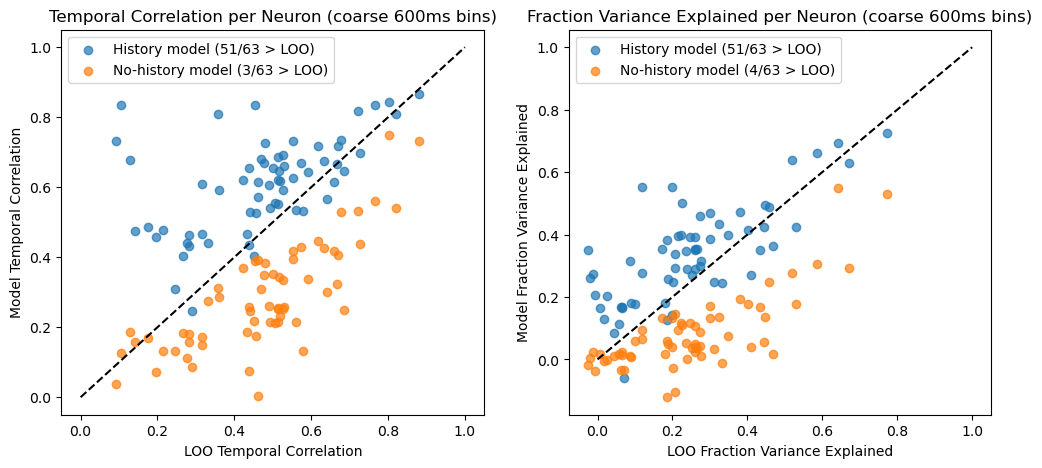

In [86]:

# Calculate improvement counts
n_total = len(loo_corrs)
hist_better_corr = (hist_corrs > loo_corrs).sum()
nohist_better_corr = (nohist_corrs > loo_corrs).sum()

hist_better_fve = (hist_fve_neurons > loo_fve_neurons).sum()
nohist_better_fve = (nohist_fve_neurons > loo_fve_neurons).sum()

f, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Temporal Correlation
ax[0].scatter(loo_corrs, hist_corrs, label=f"History model ({hist_better_corr}/{n_total} > LOO)", alpha=0.7)
ax[0].scatter(loo_corrs, nohist_corrs, label=f"No-history model ({nohist_better_corr}/{n_total} > LOO)", alpha=0.7)
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel("LOO Temporal Correlation")
ax[0].set_ylabel("Model Temporal Correlation")
ax[0].set_title(f"Temporal Correlation per Neuron (coarse {COARSE_BIN_MS}ms bins)")
ax[0].legend()  

# Plot 2: Fraction Variance Explained
ax[1].scatter(loo_fve_neurons, hist_fve_neurons, label=f"History model ({hist_better_fve}/{n_total} > LOO)", alpha=0.7)
ax[1].scatter(loo_fve_neurons, nohist_fve_neurons, label=f"No-history model ({nohist_better_fve}/{n_total} > LOO)", alpha=0.7)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel("LOO Fraction Variance Explained")
ax[1].set_ylabel("Model Fraction Variance Explained")
ax[1].set_title(f"Fraction Variance Explained per Neuron (coarse {COARSE_BIN_MS}ms bins)")
ax[1].legend()
plt.savefig(os.path.join(f'{SWEEP_DIR}/{coarse_bin_ms}_correlation_FEV_scatter.png'))
plt.show()


In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import PowerNorm
from scipy.stats import pearsonr

def plot_single_oracle_trial(pattern_name, trial_idx, model_tuple, cfg, raw_data, test_loader,
                              coarse_factor=1, coarse_method='mean',
                              nonhistory_model_tuple=None, nonhistory_cfg=None,
                              nonhistory_test_loader=None):
    """
    Plot a single oracle trial: stim polarity, actual spikes, model prediction,
    (optionally) non-history model prediction, and LOO average.
    """
    model, _, device = model_tuple
    test_dataset = test_loader.dataset
    pattern_df = raw_data["pattern_df"]
    spike_responses = raw_data["spike_responses"]
    pattern_polarities = raw_data["pattern_polarities"]
    
    output_bin_size_ms = cfg['output_bin_size_ms']
    max_time_ms = cfg['max_time_ms']
    n_input_bins = cfg['n_input_bins']
    n_output_bins = cfg['n_output_bins']
    output_offset = cfg.get('output_offset', 0)
    history = cfg.get('history', 0)
    init_state_flag = cfg.get('init_state', False)
    n_neurons = test_dataset.n_neurons
    
    total_output_bins = max_time_ms // output_bin_size_ms
    total_input_bins = max_time_ms // cfg['input_bin_size_ms']
    n_initial_state_bins = getattr(test_dataset, 'n_initial_state_bins', 0)
    
    def _bin(arr, factor, method):
        """Coarsen (neurons, fine_bins) → (neurons, coarse_bins)."""
        if factor <= 1:
            return arr
        n, fine = arr.shape
        coarse = fine // factor
        reshaped = arr[:, :coarse * factor].reshape(n, coarse, factor)
        return reshaped.sum(axis=2) if method == 'sum' else reshaped.mean(axis=2)

    def _compute_metrics(y_true, y_pred):
        if y_true.std() < 1e-9 or y_pred.std() < 1e-9:
            corr = 0.0
        else:
            corr = pearsonr(y_true.ravel(), y_pred.ravel())[0]
        mu = y_true.mean(axis=1, keepdims=True)
        numerator = np.sum((y_pred - y_true)**2)
        denominator = np.sum((y_true - mu)**2)
        r2 = 0.0 if denominator < 1e-9 else 1 - (numerator / denominator)
        return corr, r2

    def _sliding_window_predict(mdl, dev, stim_src, spikes_src, spike_binned_dict,
                                 timing, n_in, n_out, off, hist, is_init, n_init):
        """Sliding-window teacher-forced prediction for a single model."""
        tot_out = max_time_ms // output_bin_size_ms
        tot_in = max_time_ms // cfg['input_bin_size_ms']
        max_s_out = tot_out - off - n_out
        max_s_in = tot_in - n_in
        max_s = min(max_s_out, max_s_in)

        p_sum = np.zeros((n_neurons, tot_out), dtype=np.float32)
        p_cnt = np.zeros(tot_out, dtype=np.float32)

        _init = None
        if is_init and n_init > 0:
            prev = timing - 1
            if prev in spike_binned_dict:
                _init = spike_binned_dict[prev][:, -n_init:]
            else:
                _init = np.zeros((n_neurons, n_init), dtype=np.float32)

        mdl.eval()
        with torch.no_grad():
            for t in range(max_s + 1):
                se = t + n_in
                actual_bins = stim_src.shape[1]
                if se <= actual_bins:
                    xs = stim_src[:, t:se].copy()
                else:
                    xs = np.zeros((stim_src.shape[0], n_in), dtype=np.float32)
                    av = max(0, actual_bins - t)
                    if av > 0:
                        xs[:, :av] = stim_src[:, t:t+av]

                if is_init and _init is not None:
                    xs = np.pad(xs, ((0, 0), (n_init, 0)), mode='constant')

                if hist > 0:
                    if is_init and _init is not None:
                        sfl = np.concatenate([_init, spikes_src[:, t:t + n_in]], axis=1)
                    else:
                        sfl = spikes_src[:, t:t + n_in]
                    tt = xs.shape[1]
                    yh = np.zeros((n_neurons, tt), dtype=np.float32)
                    if tt > hist:
                        src = sfl[:, :tt - hist]
                        yh[:, hist:hist + src.shape[1]] = src
                    xs = np.concatenate([xs.astype(np.float32), yh], axis=0)

                bx = torch.tensor(xs, dtype=torch.float32).unsqueeze(0).to(dev)
                pr = mdl(bx).cpu().numpy()
                for o in range(n_out):
                    tb = t + off + o
                    if tb < tot_out:
                        p_sum[:, tb] += pr[0, :, o]
                        p_cnt[tb] += 1

        msk = p_cnt > 0
        pa = np.zeros_like(p_sum)
        pa[:, msk] = p_sum[:, msk] / p_cnt[msk]
        return np.exp(pa)

    # --- Get timing index for this pattern+trial ---
    unique_trials = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()
    timing_list = sorted(
        unique_trials[unique_trials['pattern_name'] == pattern_name]['pattern_timing_index'].tolist()
    )
    if trial_idx >= len(timing_list):
        raise ValueError(f"Trial {trial_idx} out of range (pattern {pattern_name} has {len(timing_list)} trials)")
    timing_idx = timing_list[trial_idx]
    
    # --- Actual response ---
    actual_response = bin_spike_response(spike_responses[timing_idx], output_bin_size_ms, max_time_ms, remainder="append")
    
    # --- LOO average ---
    other_timings = [t for t in timing_list if t != timing_idx]
    loo_avg = compute_avg_spikes_across_trials(other_timings, spike_responses, output_bin_size_ms, max_time_ms)
    
    # --- Stim and spike data ---
    stim_binned = test_dataset.pattern_stims[pattern_name]
    actual_spikes_binned = bin_spike_response(
        spike_responses[timing_idx], output_bin_size_ms, max_time_ms, remainder="append"
    )

    # --- History model prediction ---
    pred_rates = _sliding_window_predict(
        model, device, stim_binned, actual_spikes_binned,
        test_dataset.spike_responses_binned, timing_idx,
        n_input_bins, n_output_bins, output_offset,
        history, init_state_flag, n_initial_state_bins)

    # --- Nonhistory model prediction (if provided) ---
    nohist_pred_rates = None
    if nonhistory_model_tuple is not None and nonhistory_cfg is not None:
        nh_model, _, nh_device = nonhistory_model_tuple
        nh_ds = nonhistory_test_loader.dataset if nonhistory_test_loader else test_dataset
        nh_n_init = getattr(nh_ds, 'n_initial_state_bins', 0)
        nh_history = nonhistory_cfg.get('history', 0)
        nh_init_state = nonhistory_cfg.get('init_state', False)
        nh_stim = nh_ds.pattern_stims[pattern_name]

        nohist_pred_rates = _sliding_window_predict(
            nh_model, nh_device, nh_stim, actual_spikes_binned,
            nh_ds.spike_responses_binned, timing_idx,
            nonhistory_cfg['n_input_bins'], nonhistory_cfg['n_output_bins'],
            nonhistory_cfg.get('output_offset', 0),
            nh_history, nh_init_state, nh_n_init)
    
    # --- Apply coarse binning ---
    actual_response = _bin(actual_response, coarse_factor, coarse_method)
    loo_avg         = _bin(loo_avg, coarse_factor, coarse_method)
    pred_rates      = _bin(pred_rates, coarse_factor, coarse_method)
    if nohist_pred_rates is not None:
        nohist_pred_rates = _bin(nohist_pred_rates, coarse_factor, coarse_method)
    
    coarse_bin_ms = output_bin_size_ms * coarse_factor
    coarse_total_bins = actual_response.shape[1]
    display_max_ms = coarse_total_bins * coarse_bin_ms
    
    # --- Polarity plot ---
    polarity_600 = pattern_polarities[pattern_name]
    polarity_base = np.zeros((polarity_600.shape[0], max_time_ms))
    polarity_base[:, :min(600, max_time_ms)] = polarity_600[:, :min(600, max_time_ms)]
    polarity_plot = np.zeros_like(polarity_base)
    for shift in range(10):
        polarity_plot[:, shift:] += polarity_base[:, :max_time_ms - shift] if shift > 0 else polarity_base
    
    # --- Plot ---
    all_maxes = [actual_response.max(), loo_avg.max(), pred_rates.max()]
    if nohist_pred_rates is not None:
        all_maxes.append(nohist_pred_rates.max())
    local_max = max(all_maxes)
    # spike_vmax = max(1.0, local_max) + 0.2
    spike_vmax = 3.4

    pnorm = PowerNorm(gamma=0.5, vmin=0, vmax=spike_vmax)
    spike_cmap = plt.cm.Greys
    bright_polarity_cmap = ListedColormap(["#1E8FFF", '#FFFFFF', "#D02525"])
    
    agg_label = coarse_method if coarse_factor > 1 else ""
    bin_label = f"{coarse_bin_ms}ms bins" + (f", {agg_label}" if agg_label else "")

    n_panels = 5 if nohist_pred_rates is not None else 4
    fig, axes = plt.subplots(n_panels, 1, figsize=(6, 2 * n_panels), constrained_layout=True)
    
    # Panel 0: Stimulation
    axes[0].imshow(polarity_plot, aspect='auto', cmap=bright_polarity_cmap, vmin=-1, vmax=1,
                   interpolation='nearest', extent=[0, max_time_ms, polarity_plot.shape[0], 0])
    axes[0].set_title(f"Pattern {pattern_name} – Trial {trial_idx} – Stimulation")
    axes[0].set_ylabel('Channel')
    axes[0].axvline(x=600, color='gray', linestyle='--', linewidth=1)
    
    # Panel 1: Actual spikes
    axes[1].imshow(actual_response, aspect='auto', cmap=spike_cmap, norm=pnorm,
                   interpolation='nearest', extent=[0, display_max_ms, n_neurons, 0])
    axes[1].set_title(f'Actual spikes ({bin_label})')
    axes[1].set_ylabel('Neuron')
    axes[1].axvline(x=600, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    # Panel 2: History model prediction
    im2 = axes[2].imshow(pred_rates, aspect='auto', cmap=spike_cmap, norm=pnorm,
                   interpolation='nearest', extent=[0, display_max_ms, n_neurons, 0])
    hist_label = f" (history={history})" if history > 0 else ""
    axes[2].set_title(f'History model prediction{hist_label} ({bin_label})')
    axes[2].set_ylabel('Neuron')
    axes[2].axvline(x=600, color='red', linestyle='--', linewidth=1, alpha=0.7)

    if nohist_pred_rates is not None:
        # Panel 3: Non-history model prediction
        axes[3].imshow(nohist_pred_rates, aspect='auto', cmap=spike_cmap, norm=pnorm,
                       interpolation='nearest', extent=[0, display_max_ms, n_neurons, 0])
        axes[3].set_title(f'No-history model prediction ({bin_label})')
        axes[3].set_ylabel('Neuron')
        axes[3].axvline(x=600, color='red', linestyle='--', linewidth=1, alpha=0.7)
        loo_panel = 4
    else:
        loo_panel = 3
    
    # LOO panel
    axes[loo_panel].imshow(loo_avg, aspect='auto', cmap=spike_cmap, norm=pnorm,
                   interpolation='nearest', extent=[0, display_max_ms, n_neurons, 0])
    axes[loo_panel].set_title(f'LOO avg over {len(other_timings)} other trials ({bin_label})')
    axes[loo_panel].set_ylabel('Neuron')
    axes[loo_panel].set_xlabel('Time (ms)')
    axes[loo_panel].axvline(x=600, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    fig.colorbar(im2, ax=axes[1:].tolist(), orientation='vertical', shrink=0.8, label='Spike count')
    plt.savefig(f"results/scratch/oracle_trial_{pattern_name}_trial{trial_idx}_coarse{coarse_bin_ms}ms.png", dpi=300, bbox_inches='tight', transparent=False)
    plt.show()
    return fig

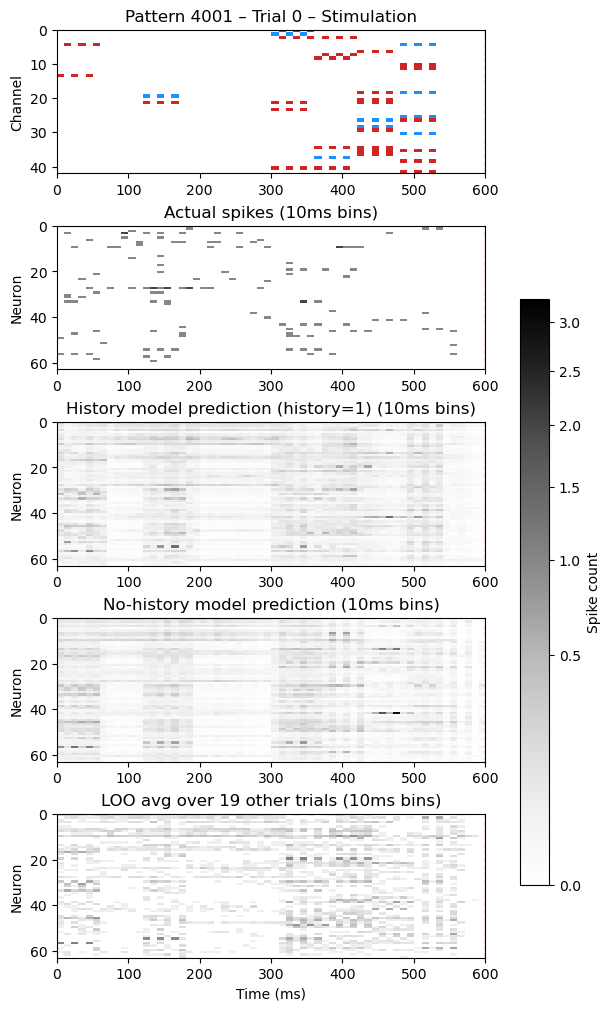

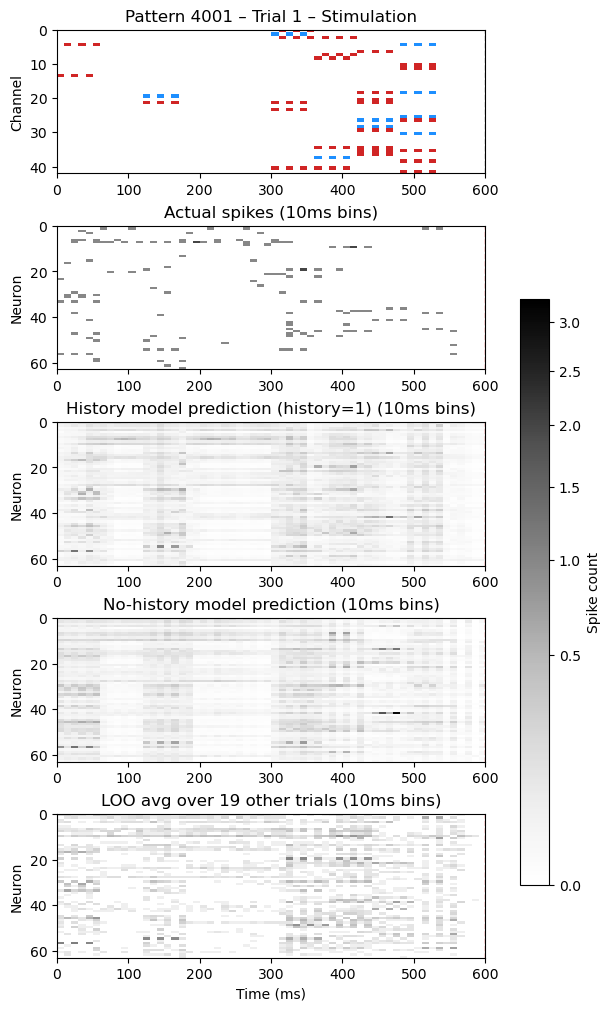

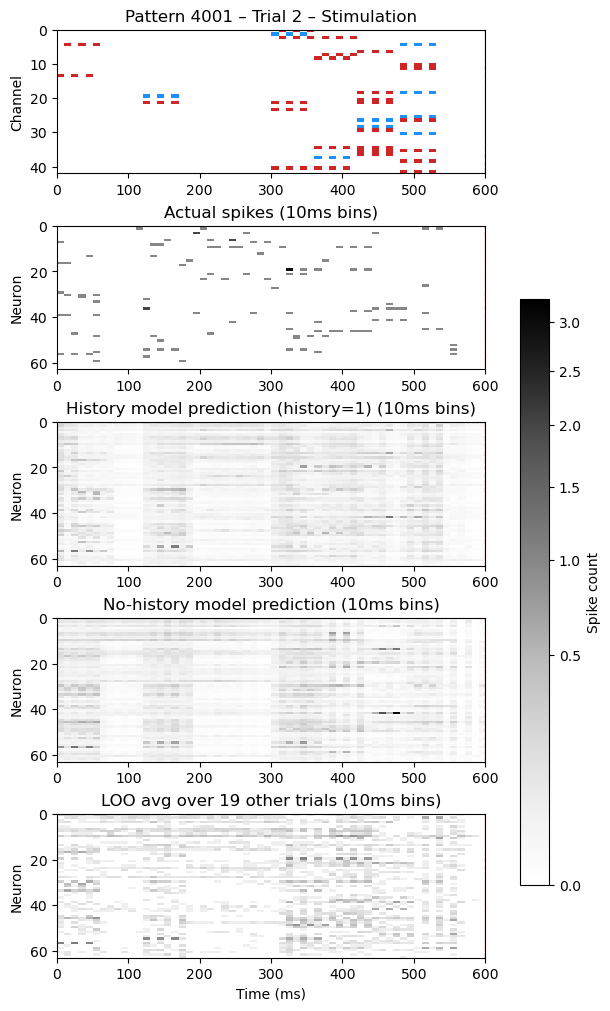

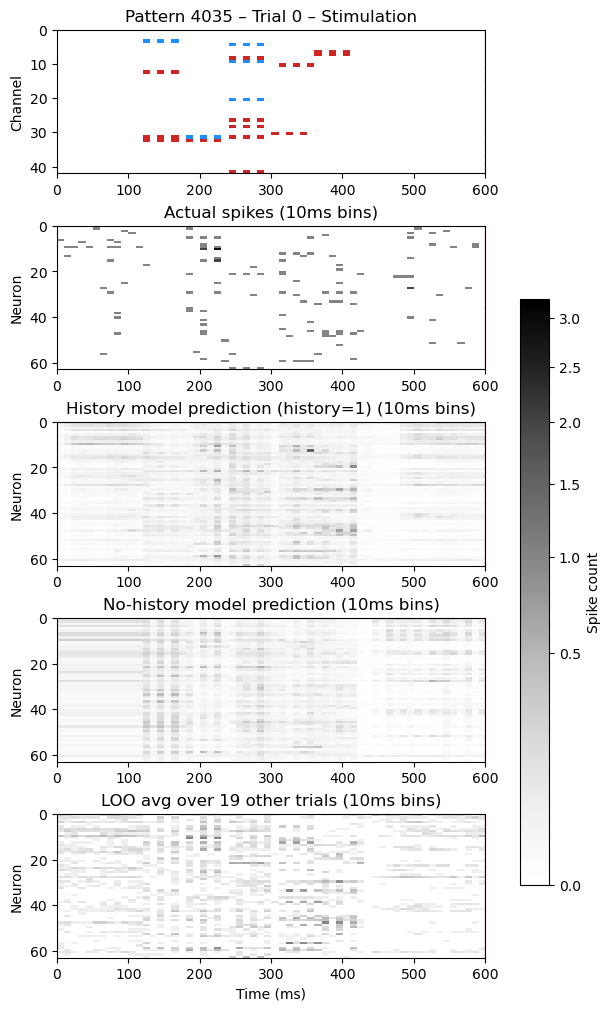

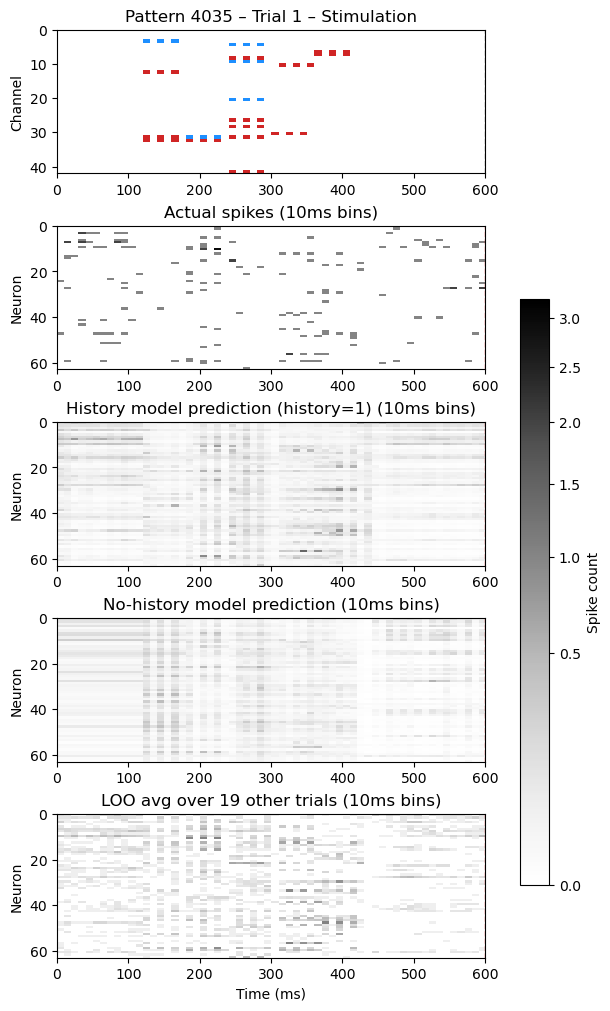

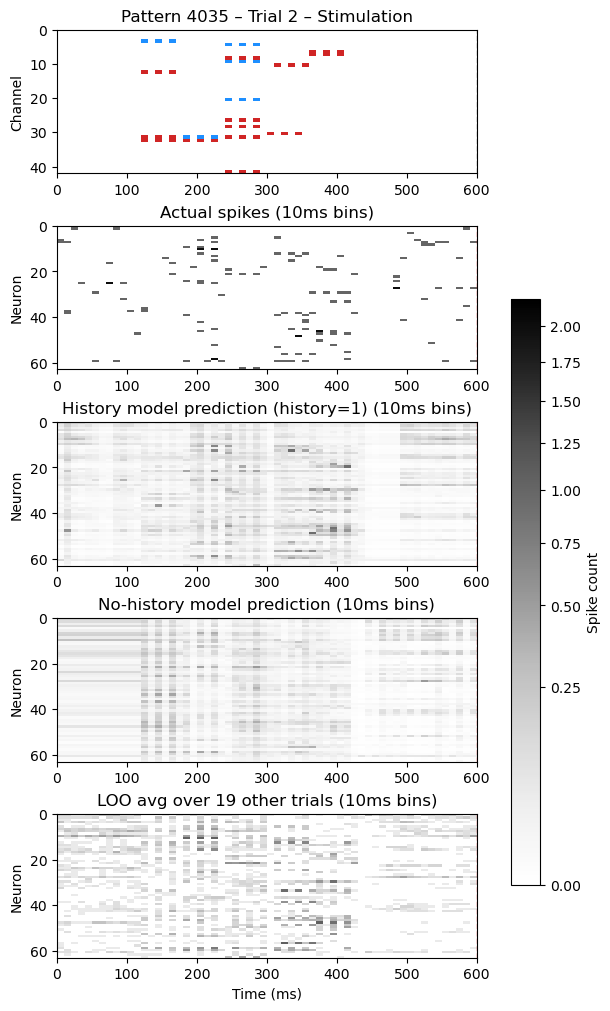

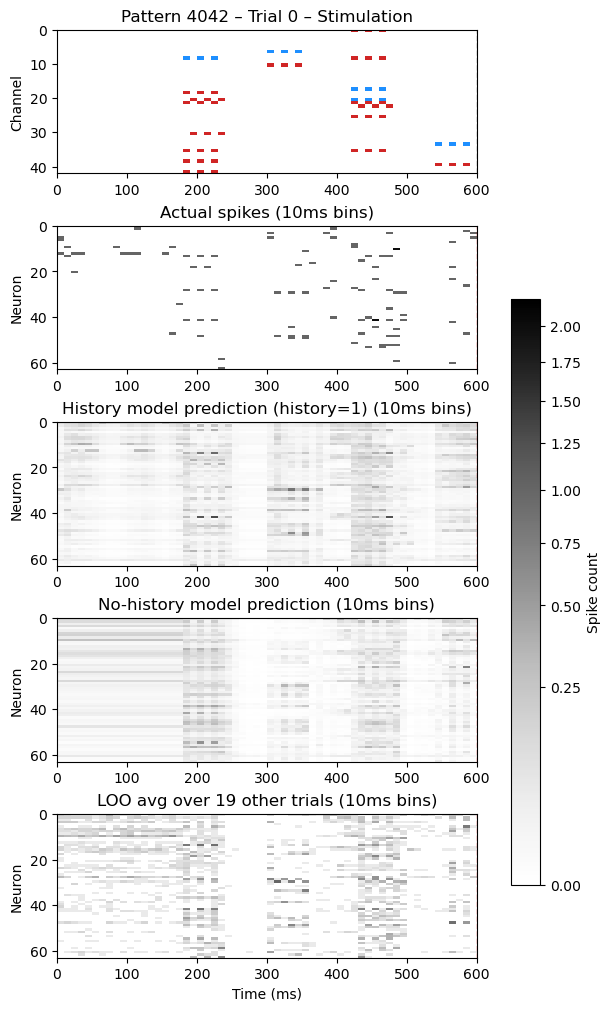

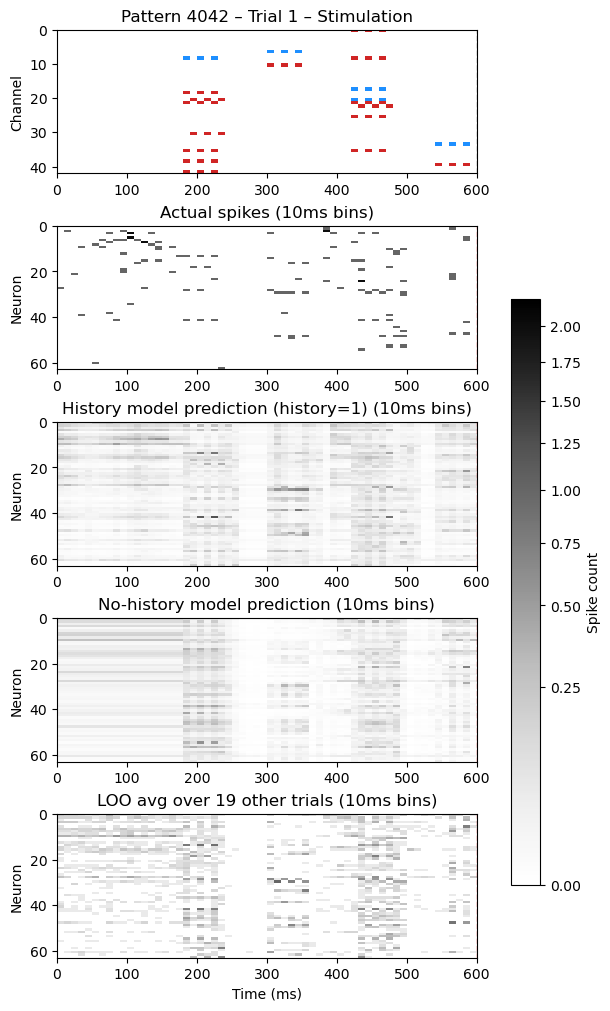

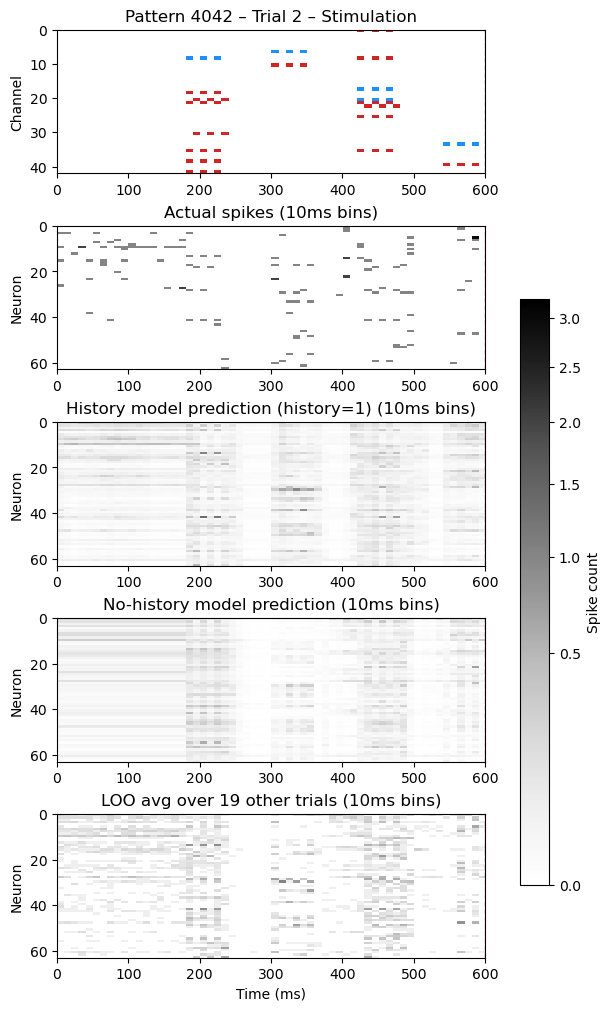

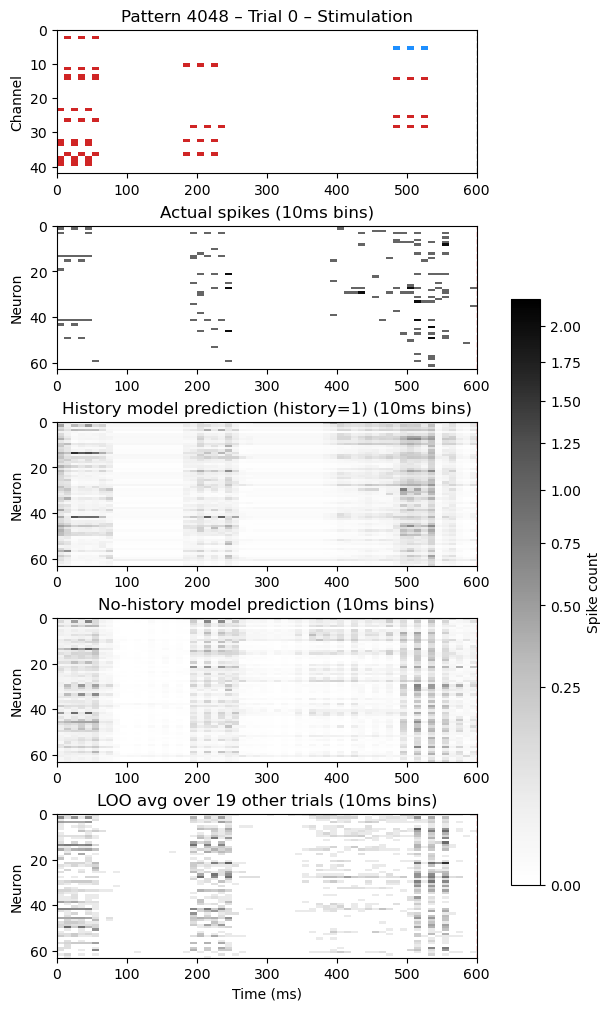

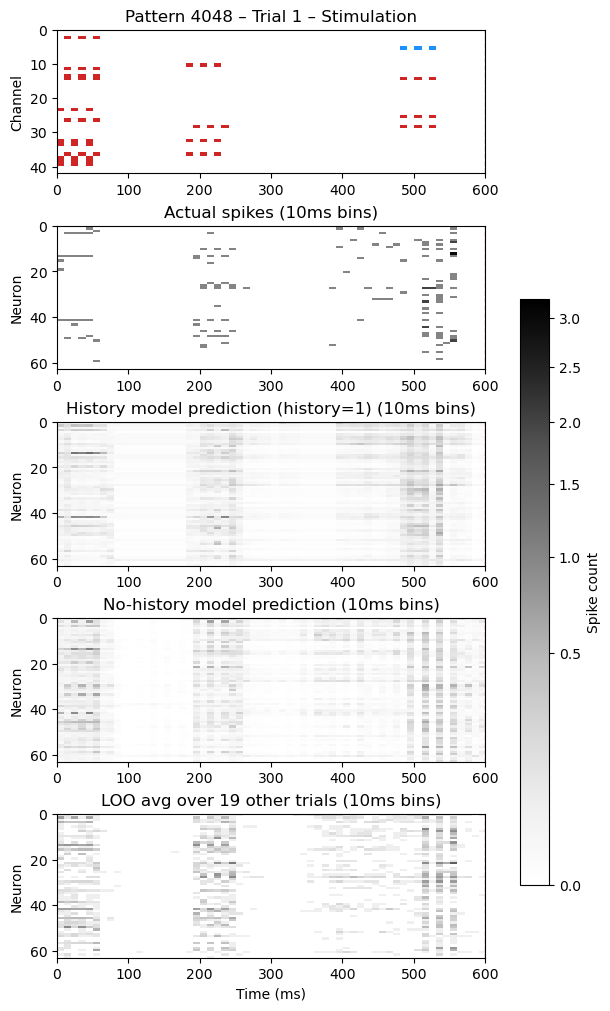

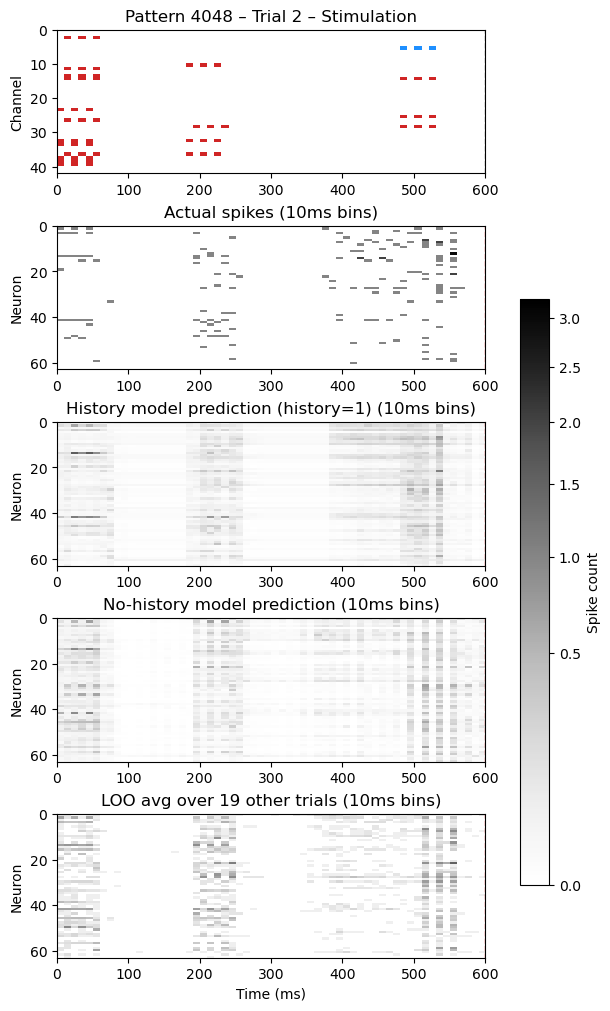

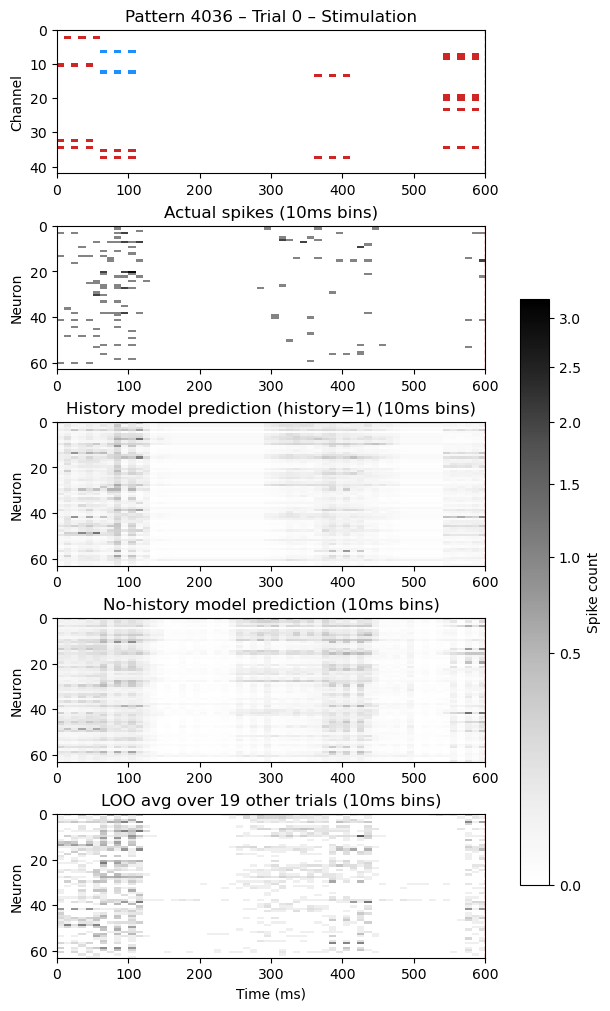

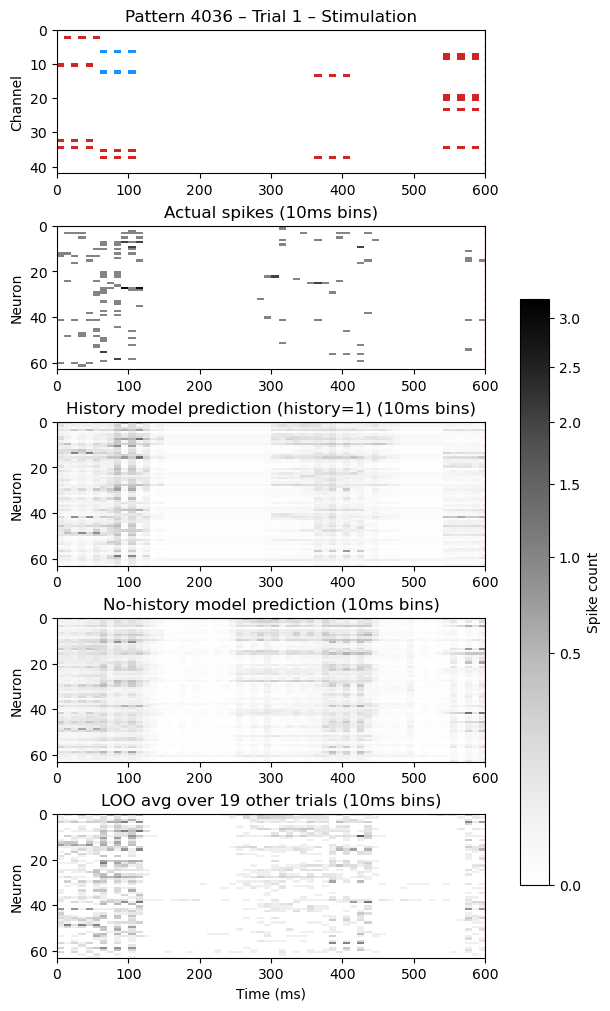

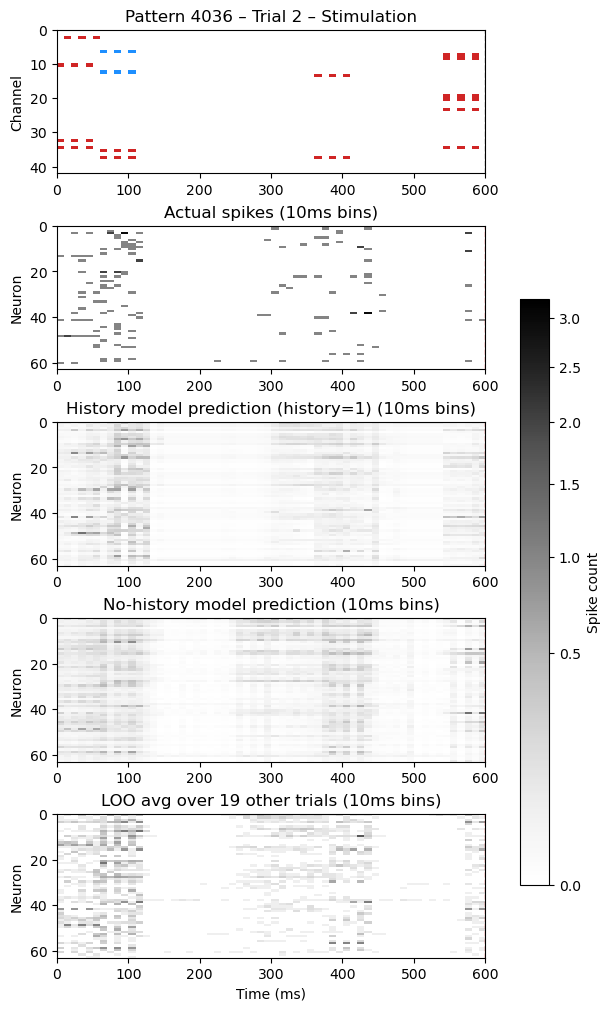

In [109]:

# --- Example usage ---
for pattern in [4001, 4035, 4042, 4048, 4036]:
    for trial in range(3):
        fig = plot_single_oracle_trial(pattern, trial, history_model, history_cfg, history_raw, test_loader,
                                    coarse_factor=1, coarse_method='mean',
                                    nonhistory_model_tuple=nonhistory_model,
                                    nonhistory_cfg=nonhistory_cfg,
                                    nonhistory_test_loader=nonhistory_test_loader)

In [89]:
# --- Load best model per history value, collect predictions/targets ---
import pandas as pd
import os

SWEEP_DIR = 'results/hist_cnn_initstate_v3_2026-02-19_18-40-39'

COARSE_FACTOR = 1       # 60ms bins; change to 0 for fine (10ms) bins

# 1. Find best trial per history from sweep CSV
sweep_df = pd.read_csv(os.path.join(SWEEP_DIR, 'sweep_results.csv'))
best_idx = sweep_df.groupby('history')['test_corr'].idxmax()
best_df = sweep_df.loc[best_idx].sort_values('history').reset_index(drop=True)

print(f"Loading {len(best_df)} models (coarse_factor={COARSE_FACTOR})...")

# 2. For each history value, load model & store predictions/targets
history_values = []
model_kernel_sizes = []
sweep_preds = []    # list of (pred, true) arrays per history
sweep_loaders = []  # keep loaders for correlation

for _, row in best_df.iterrows():
    run_dir = row['run_dir']
    h = int(row['history'])
    history_values.append(h)
    
    model_tuple, cfg, raw_data, loader = open_model_and_data(run_dir)
    # Extract kernel size (assuming single kernel size in list like [60])
    ks = cfg.get('kernel_sizes', [60])
    model_kernel_sizes.append(str(ks[0]) if isinstance(ks, list) and len(ks) > 0 else str(ks))
    
    pred, true = collect_model_preds_and_targets(model_tuple, loader, coarse_factor=COARSE_FACTOR)
    sweep_preds.append((pred, true))
    sweep_loaders.append(loader)
    print(f"  history={h:>2d}  ks= {model_kernel_sizes[-1]}  run={run_dir.split('/')[-1]}  shape={pred.shape}")

print("Done. Use sweep_preds / sweep_loaders for FEV and correlation plots.")

Loading 7 models (coarse_factor=1)...
Loading data …
63 unique neurons after dropping problematic neurons
Stimulation channels: 42, Spiking neurons: 63
Unique patterns: 4050, Total trials: 5000
Added init state spikes for trial  -1  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  0  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes for trial  3  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  4  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes f

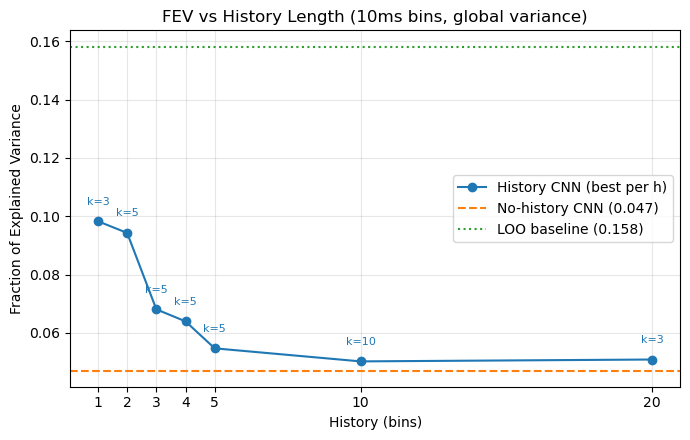

In [90]:
# --- FEV vs History ---
import matplotlib.pyplot as plt

# Dynamically compute baselines at sweep's COARSE_FACTOR
_loo_pred, _loo_true = collect_loo_preds_and_targets(sweep_loaders[0].dataset, coarse_factor=COARSE_FACTOR, loo_flag=True)
_, LOO_FVE_MEAN = fraction_variance_explained(_loo_true, _loo_pred, global_variance=True)

_nh_pred, _nh_true = collect_model_preds_and_targets(nonhistory_model, nonhistory_test_loader, coarse_factor=COARSE_FACTOR)
_, nohist_fve_mean = fraction_variance_explained(_nh_true, _nh_pred, global_variance=True)

fve_means = []
for pred, true in sweep_preds:
    _, fve_mean = fraction_variance_explained(true, pred, global_variance=True)
    fve_means.append(fve_mean)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history_values, fve_means, 'o-', color='tab:blue', label='History CNN (best per h)')

# Annotate with Kernel Size
for i, h in enumerate(history_values):
    ks = model_kernel_sizes[i]
    ax.text(h, fve_means[i] + 0.005, f'k={ks}', ha='center', va='bottom', fontsize=8, color='tab:blue')

ax.axhline(nohist_fve_mean, color='tab:orange', ls='--', lw=1.5, label=f'No-history CNN ({nohist_fve_mean:.3f})')
ax.axhline(LOO_FVE_MEAN, color='tab:green', ls=':', lw=1.5, label=f'LOO baseline ({LOO_FVE_MEAN:.3f})')
ax.set_xlabel('History (bins)')
ax.set_ylabel('Fraction of Explained Variance')

coarse_bin_ms = fine_bin_ms * COARSE_FACTOR if COARSE_FACTOR > 0 else fine_bin_ms
ax.set_title(f'FEV vs History Length ({coarse_bin_ms}ms bins, global variance)')
ax.set_xticks(history_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SWEEP_DIR, f'FEV_vs_history_coarse{coarse_bin_ms}ms.png'), dpi=300, bbox_inches='tight', transparent=False)
plt.show()

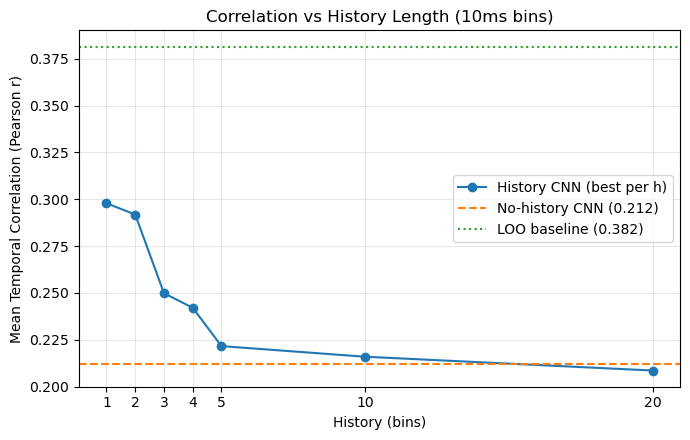

In [91]:
%matplotlib inline
# --- Temporal Correlation vs History ---

# Dynamically compute baselines at sweep's COARSE_FACTOR
loo_corrs = get_loo_temporal_corr(sweep_loaders[0].dataset, coarse_factor=COARSE_FACTOR)
loo_corr_mean = loo_corrs.mean()

nohist_corrs = get_per_neuron_temporal_corr(nonhistory_model, nonhistory_test_loader, coarse_factor=COARSE_FACTOR)
nohist_corr_mean = nohist_corrs.mean()

corr_means = []
for pred, true in sweep_preds:
    n_neurons_here = pred.shape[1]
    neuron_corrs = np.zeros(n_neurons_here)
    for n in range(n_neurons_here):
        p = pred[:, n, :].ravel()
        t = true[:, n, :].ravel()
        if p.std() > 1e-8 and t.std() > 1e-8:
            neuron_corrs[n] = pearsonr(p, t)[0]
    corr_means.append(neuron_corrs.mean())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history_values, corr_means, 'o-', color='tab:blue', label='History CNN (best per h)')
ax.axhline(nohist_corr_mean, color='tab:orange', ls='--', lw=1.5, label=f'No-history CNN ({nohist_corr_mean:.3f})')
ax.axhline(loo_corr_mean, color='tab:green', ls=':', lw=1.5, label=f'LOO baseline ({loo_corr_mean:.3f})')
ax.set_xlabel('History (bins)')
ax.set_ylabel('Mean Temporal Correlation (Pearson r)')
coarse_bin_ms = fine_bin_ms * COARSE_FACTOR if COARSE_FACTOR > 0 else fine_bin_ms
ax.set_title(f'Correlation vs History Length ({coarse_bin_ms}ms bins)')
ax.set_xticks(history_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

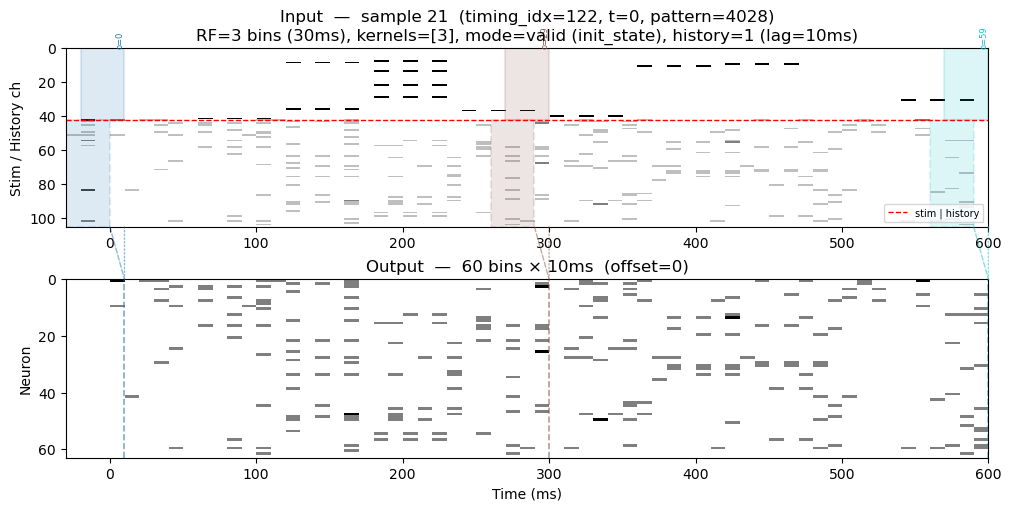

In [60]:
f = test_loader.dataset.visualize_sample(21, cfg=history_cfg)
plt.show()

In [52]:
long_history_model, _, _, long_history_loader = open_model_and_data('results/hist_cnn_initstate_v3_2026-02-19_18-40-39/trial_0055_history=20') 

Loading data …
63 unique neurons after dropping problematic neurons
Stimulation channels: 42, Spiking neurons: 63
Unique patterns: 4050, Total trials: 5000
Added init state spikes for trial  -1  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  0  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes for trial  3  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  4  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes for trial  8  from non-specified set of

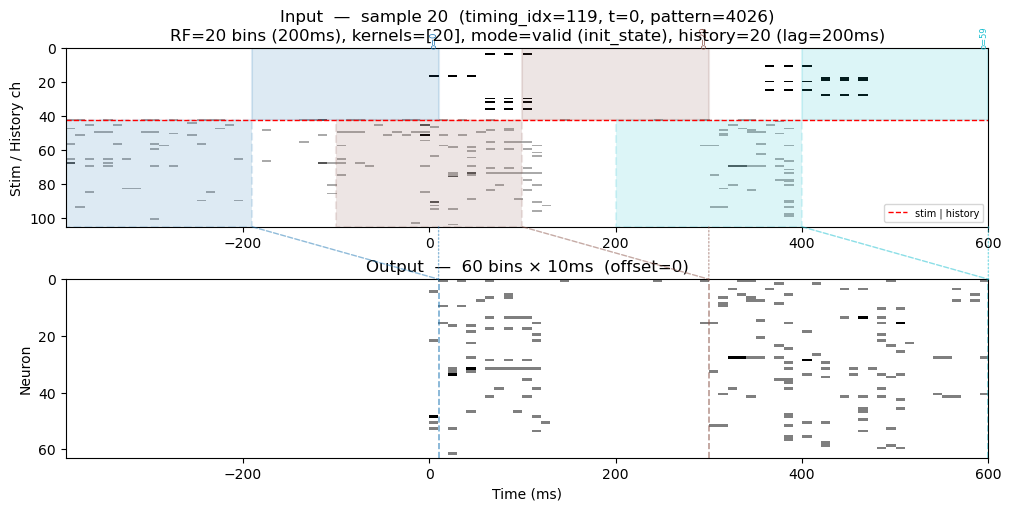

In [61]:
long_history_cfg = yaml.safe_load(open('results/hist_cnn_initstate_v3_2026-02-19_18-40-39/trial_0055_history=20/config.yaml'))
f = long_history_loader.dataset.visualize_sample(20, cfg=long_history_cfg)
plt.show()

In [93]:
init_cfg = yaml.safe_load(open('results/hist_cnn_v3_2026-02-19_14-35-39/trial_0047_history=20/config.yaml'))
init_model, _, _, init_loader = open_model_and_data('results/hist_cnn_v3_2026-02-19_14-35-39/trial_0047_history=20/') 


Loading data …
63 unique neurons after dropping problematic neurons
Stimulation channels: 42, Spiking neurons: 63
Unique patterns: 4050, Total trials: 5000
Added init state spikes for trial  -1  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  0  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes for trial  3  from non-specified set of trials for full trial length number of output bins
This is needed to provide initial state for the first few bins of trial  4  when init_state is True but the previous trial's response spikes are not included in the dataset (e.g., when trial_indices does not include all trials or when timing_idx - 1 is not in trial_indices)
Added init state spikes for trial  8  from non-specified set of

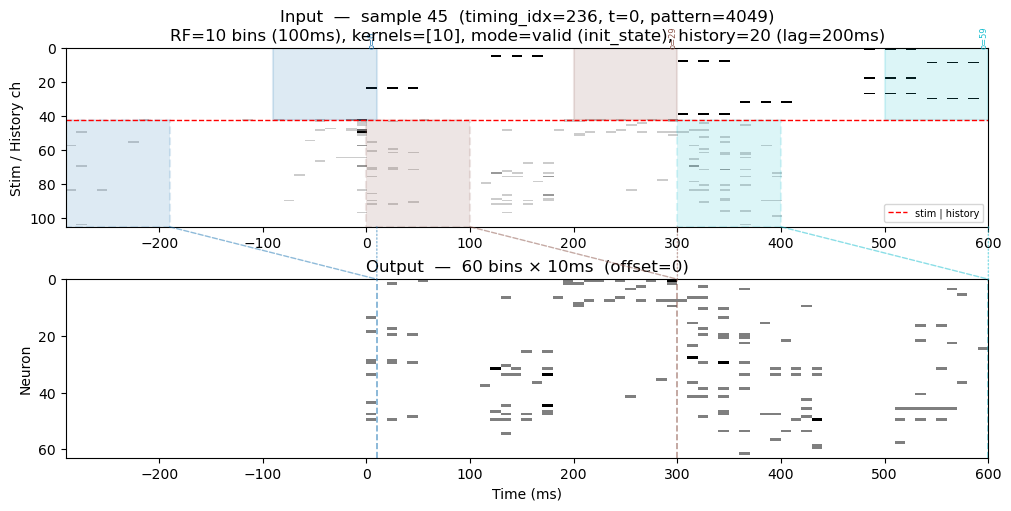

In [97]:
f = init_loader.dataset.visualize_sample(45, cfg=init_cfg)
plt.show()

In [ ]:
def plot_neuron_pattern_traces(neuron_idx, pattern_name, model_tuple, cfg, raw_data, test_loader,
                                coarse_factor=1, coarse_method='mean', save_dir=None):
    """
    Two-panel figure for one neuron × one oracle pattern.

    Top: mean ± SEM spike response across trials + mean model prediction.
    Bottom: all individual trial traces (vertically offset) + model prediction
            traces overlaid.

    Args:
        neuron_idx: int, neuron index (0-based)
        pattern_name: pattern identifier
        model_tuple: (model, cfg_unused, device)
        cfg: model config dict
        raw_data: output of load_raw_data
        test_loader: DataLoader (only .dataset used)
        coarse_factor: temporal coarsening factor (1 = no coarsening)
        coarse_method: 'mean' or 'sum'
        save_dir: if not None, save figure there and close it

    Returns:
        fig (or None if saved and closed)
    """
    model, _, device = model_tuple
    test_dataset = test_loader.dataset
    pattern_df = raw_data["pattern_df"]
    spike_responses = raw_data["spike_responses"]

    output_bin_size_ms = cfg['output_bin_size_ms']
    max_time_ms = cfg['max_time_ms']
    n_input_bins = cfg['n_input_bins']
    n_output_bins = cfg['n_output_bins']
    output_offset = cfg.get('output_offset', 0)
    history = cfg.get('history', 0)
    init_state_flag = cfg.get('init_state', False)
    n_neurons_total = test_dataset.n_neurons
    n_initial_state_bins = getattr(test_dataset, 'n_initial_state_bins', 0)

    total_output_bins = max_time_ms // output_bin_size_ms

    def _bin_1d(arr, factor, method):
        if factor <= 1:
            return arr
        n = len(arr)
        coarse = n // factor
        reshaped = arr[:coarse * factor].reshape(coarse, factor)
        return reshaped.sum(axis=1) if method == 'sum' else reshaped.mean(axis=1)

    def _sliding_window_predict_single(mdl, dev, stim_src, spikes_src, spike_binned_dict,
                                        timing):
        """Sliding-window teacher-forced prediction → (n_neurons, total_output_bins)."""
        tot_out = max_time_ms // output_bin_size_ms
        tot_in = max_time_ms // cfg['input_bin_size_ms']
        max_s = min(tot_out - output_offset - n_output_bins, tot_in - n_input_bins)

        p_sum = np.zeros((n_neurons_total, tot_out), dtype=np.float32)
        p_cnt = np.zeros(tot_out, dtype=np.float32)

        _init = None
        if init_state_flag and n_initial_state_bins > 0:
            prev = timing - 1
            if prev in spike_binned_dict:
                _init = spike_binned_dict[prev][:, -n_initial_state_bins:]
            else:
                _init = np.zeros((n_neurons_total, n_initial_state_bins), dtype=np.float32)

        mdl.eval()
        with torch.no_grad():
            for t in range(max_s + 1):
                se = t + n_input_bins
                actual_bins = stim_src.shape[1]
                if se <= actual_bins:
                    xs = stim_src[:, t:se].copy()
                else:
                    xs = np.zeros((stim_src.shape[0], n_input_bins), dtype=np.float32)
                    av = max(0, actual_bins - t)
                    if av > 0:
                        xs[:, :av] = stim_src[:, t:t+av]

                if init_state_flag and _init is not None:
                    xs = np.pad(xs, ((0, 0), (n_initial_state_bins, 0)), mode='constant')

                if history > 0:
                    if init_state_flag and _init is not None:
                        sfl = np.concatenate([_init, spikes_src[:, t:t + n_input_bins]], axis=1)
                    else:
                        sfl = spikes_src[:, t:t + n_input_bins]
                    tt = xs.shape[1]
                    yh = np.zeros((n_neurons_total, tt), dtype=np.float32)
                    if tt > history:
                        src = sfl[:, :tt - history]
                        yh[:, history:history + src.shape[1]] = src
                    xs = np.concatenate([xs.astype(np.float32), yh], axis=0)

                bx = torch.tensor(xs, dtype=torch.float32).unsqueeze(0).to(dev)
                pr = mdl(bx).cpu().numpy()
                for o in range(n_output_bins):
                    tb = t + output_offset + o
                    if tb < tot_out:
                        p_sum[:, tb] += pr[0, :, o]
                        p_cnt[tb] += 1

        msk = p_cnt > 0
        pa = np.zeros_like(p_sum)
        pa[:, msk] = p_sum[:, msk] / p_cnt[msk]
        return np.exp(pa)

    # --- Gather all trials for this pattern ---
    unique_trials = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()
    timing_list = sorted(
        unique_trials[unique_trials['pattern_name'] == pattern_name]['pattern_timing_index'].tolist()
    )
    n_trials = len(timing_list)

    stim_binned = test_dataset.pattern_stims[pattern_name]

    all_actual = []   # list of 1-d arrays (coarse_bins,)
    all_pred   = []

    for timing_idx in timing_list:
        # Actual binned spikes for this neuron
        actual_full = bin_spike_response(spike_responses[timing_idx],
                                         output_bin_size_ms, max_time_ms, remainder="append")
        actual_neuron = actual_full[neuron_idx]  # (total_output_bins,)

        # Model prediction for this trial
        pred_full = _sliding_window_predict_single(
            model, device, stim_binned, actual_full,
            test_dataset.spike_responses_binned, timing_idx)
        pred_neuron = pred_full[neuron_idx]

        all_actual.append(_bin_1d(actual_neuron, coarse_factor, coarse_method))
        all_pred.append(_bin_1d(pred_neuron, coarse_factor, coarse_method))

    all_actual = np.array(all_actual)  # (n_trials, coarse_bins)
    all_pred   = np.array(all_pred)

    n_bins = all_actual.shape[1]
    coarse_bin_ms = output_bin_size_ms * coarse_factor
    time_ms = np.arange(n_bins) * coarse_bin_ms + coarse_bin_ms / 2  # bin centres

    actual_mean = all_actual.mean(axis=0)
    actual_sem  = all_actual.std(axis=0) / np.sqrt(n_trials)
    pred_mean   = all_pred.mean(axis=0)
    pred_sem    = all_pred.std(axis=0) / np.sqrt(n_trials)

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # Top: Mean ± SEM
    axes[0].plot(time_ms, actual_mean, color='black', lw=1.5, label='Actual (mean)')
    axes[0].fill_between(time_ms, actual_mean - actual_sem, actual_mean + actual_sem,
                         color='black', alpha=0.15)
    axes[0].plot(time_ms, pred_mean, color='tab:red', lw=1.5, label='Model pred (mean)')
    axes[0].fill_between(time_ms, pred_mean - pred_sem, pred_mean + pred_sem,
                         color='tab:red', alpha=0.15)
    axes[0].set_ylabel('Spike count / rate')
    axes[0].set_title(f'Neuron {neuron_idx} — Pattern {pattern_name}  '
                      f'({n_trials} trials, {coarse_bin_ms}ms bins)')
    axes[0].legend(fontsize=8)
    axes[0].axvline(x=600, color='gray', ls='--', lw=0.8)
    axes[0].set_xlim(time_ms[0] - coarse_bin_ms / 2, time_ms[-1] + coarse_bin_ms / 2)

    # Bottom: individual traces offset
    for k in range(n_trials):
        axes[1].plot(time_ms, all_actual[k], color='black', lw=0.6, alpha=0.7)
        axes[1].plot(time_ms, all_pred[k], color='tab:red', lw=0.6, alpha=0.7)

    axes[1].set_ylabel('Firing rate')
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_title('Individual trial traces (black=actual, red=model)')
    axes[1].axvline(x=600, color='gray', ls='--', lw=0.8)
    axes[1].set_xlim(time_ms[0] - coarse_bin_ms / 2, time_ms[-1] + coarse_bin_ms / 2)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        fname = os.path.join(save_dir, f'neuron{neuron_idx:03d}_pattern{pattern_name}.png')
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.close(fig)
        return None
    plt.show()
    return fig


def generate_all_neuron_pattern_plots(model_tuple, cfg, raw_data, test_loader,
                                       coarse_factor=1, coarse_method='mean',
                                       save_dir='results/neuron_pattern_traces',
                                       neuron_indices=None):
    """
    Generate per-neuron per-pattern trace figures for all oracle patterns.

    Args:
        neuron_indices: list of neuron indices, or None → all neurons.
        Other args: same as plot_neuron_pattern_traces.
    """
    pattern_df = raw_data["pattern_df"]
    unique_trials = pattern_df[['pattern_name', 'is_oracle']].drop_duplicates()
    oracle_patterns = sorted(unique_trials[unique_trials['is_oracle']]['pattern_name'].unique())

    n_neurons_total = test_loader.dataset.n_neurons
    if neuron_indices is None:
        neuron_indices = list(range(n_neurons_total))

    total = len(neuron_indices) * len(oracle_patterns)
    print(f"Generating {total} figures ({len(neuron_indices)} neurons × {len(oracle_patterns)} patterns) → {save_dir}/")

    for count, neuron_idx in enumerate(neuron_indices):
        for pat in oracle_patterns:
            plot_neuron_pattern_traces(
                neuron_idx, pat, model_tuple, cfg, raw_data, test_loader,
                coarse_factor=coarse_factor, coarse_method=coarse_method,
                save_dir=save_dir)
        done = (count + 1) * len(oracle_patterns)
        print(f"  Neuron {neuron_idx:>3d} done  ({done}/{total})")

    print("All figures saved.")

In [104]:
# # --- Single example ---
fig = plot_neuron_pattern_traces(5, 4031, history_model, history_cfg, history_raw, test_loader,
                                 coarse_factor=6, save_dir='results/scratch/single_trace_examples_coarse6')

# --- Generate all (uncomment to run; saves ~3150 figures) ---
# generate_all_neuron_pattern_plots(history_model, history_cfg, history_raw, test_loader,
#                                    coarse_factor=1,
#                                    save_dir='results/neuron_pattern_traces_coarse1')